In [ ]:
# IMPORTS

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"NumPy version      : {np.__version__}")

TensorFlow version : 2.21.0
Keras version      : 3.13.2
NumPy version      : 2.4.2


In [ ]:
# CONFIGURATION


# Paths
DATASET_ROOT    = Path(r"C:\Users\asus\OneDrive\Documents\AI DOE\train1")
INFERENCE_DIR   = Path(r"C:\Users\asus\OneDrive\Documents\AI DOE\test")
MODEL_SAVE_DIR  = Path(r"C:\Users\asus\OneDrive\Documents\AI DOE\saved_models")

# Image & batch settings
IMG_SIZE   = 128
BATCH_SIZE = 32

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Training
STAGE1_EPOCHS    = 20
STAGE2_EPOCHS    = 20
STAGE1_LR        = 1e-3
STAGE2_LR        = 1e-5
FINE_TUNE_LAYERS = 30

SEED = 42

# Class names
CLASS_NAMES = [
    "articulated_truck",
    "background",
    "bicycle",
    "bus",
    "car",
    "motorcycle",
    "non-motorized_vehicle",
    "pedestrian",
    "pickup_truck",
    "single_unit_truck",
    "work_van"
]
NUM_CLASSES   = len(CLASS_NAMES)
CLASS_TO_IDX  = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS  = {idx: name for name, idx in CLASS_TO_IDX.items()}

print("Configuration loaded successfully.")
print(f"  Image size    : {IMG_SIZE} × {IMG_SIZE}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Num classes   : {NUM_CLASSES}")
print(f"  Train / Val / Test split: {int(TRAIN_RATIO*100)} / "
      f"{int(VAL_RATIO*100)} / {int(TEST_RATIO*100)}")

Configuration loaded successfully.
  Image size    : 128 × 128
  Batch size    : 32
  Num classes   : 11
  Train / Val / Test split: 70 / 15 / 15


In [ ]:
# REPRODUCIBILITY AND GPU SETUP

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Detect GPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✓ GPU detected: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"    └─ {gpu.name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE = "GPU"
else:
    print("⚠  No GPU detected. Running on CPU.")
    print("   Training will be slower. You can reduce STAGE1_EPOCHS and")
    print("   STAGE2_EPOCHS in the Configuration cell to save time.")
    DEVICE = "CPU"

print(f"\nActive compute device: {DEVICE}")

⚠  No GPU detected. Running on CPU.
   Training will be slower. You can reduce STAGE1_EPOCHS and
   STAGE2_EPOCHS in the Configuration cell to save time.

Active compute device: CPU


In [ ]:
# PATH VALIDATION

def check_paths():
    all_ok = True

    # Check dataset root
    if not DATASET_ROOT.exists():
        print(f"[ERROR] Dataset root NOT found:\n  {DATASET_ROOT}")
        print("  → Please update DATASET_ROOT in the Configuration cell.")
        all_ok = False
    else:
        print(f"[OK] Dataset root found: {DATASET_ROOT}")

    # Check each class folder
    if DATASET_ROOT.exists():
        missing = []
        for cls in CLASS_NAMES:
            cls_path = DATASET_ROOT / cls
            if not cls_path.is_dir():
                missing.append(cls)
        if missing:
            print(f"[WARNING] {len(missing)} class folder(s) not found: {missing}")
        else:
            print(f"[OK] All {NUM_CLASSES} class folders present.")

    # Check inference folder
    if not INFERENCE_DIR.exists():
        print(f"[WARNING] Inference folder not found:\n  {INFERENCE_DIR}")
        print("  → Section J (Inference) will not work until this folder exists.")
    else:
        n_inf = len(list(INFERENCE_DIR.iterdir()))
        print(f"[OK] Inference folder found: {n_inf} file(s) inside.")

    # Create model save directory
    MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"[OK] Model save directory ready: {MODEL_SAVE_DIR}")

    return all_ok

paths_ok = check_paths()
if not paths_ok:
    raise SystemExit("Fix the path errors above before continuing.")

[OK] Dataset root found: C:\Users\asus\OneDrive\Documents\AI DOE\train1
[OK] All 11 class folders present.
[OK] Inference folder found: 129795 file(s) inside.
[OK] Model save directory ready: C:\Users\asus\OneDrive\Documents\AI DOE\saved_models


In [ ]:
# COLLECT ALL FILE PATHS AND INTEGER LABELS

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

all_paths  = []
all_labels = []

for cls_name in CLASS_NAMES:
    cls_folder = DATASET_ROOT / cls_name
    if not cls_folder.is_dir():
        print(f"[SKIP] Folder not found: {cls_folder}")
        continue
    cls_idx = CLASS_TO_IDX[cls_name]
    for img_file in cls_folder.iterdir():
        if img_file.suffix.lower() in VALID_EXTENSIONS:
            all_paths.append(str(img_file))
            all_labels.append(cls_idx)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

print(f"Total images collected: {len(all_paths):,}")
print()
print(f"{'Class':<30} {'Index':>5}  {'Count':>6}")
print("-" * 45)
for cls_name in CLASS_NAMES:
    idx   = CLASS_TO_IDX[cls_name]
    count = int(np.sum(all_labels == idx))
    print(f"{cls_name:<30} {idx:>5}  {count:>6,}")

Total images collected: 52,801

Class                          Index   Count
---------------------------------------------
articulated_truck                  0   4,991
background                         1   7,296
bicycle                            2   2,284
bus                                3   5,102
car                                4   6,268
motorcycle                         5   1,982
non-motorized_vehicle              6   1,751
pedestrian                         7   6,262
pickup_truck                       8   6,290
single_unit_truck                  9   5,120
work_van                          10   5,455


In [ ]:
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT

# Step 1: Hold out 15% for testing
X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_paths,
    all_labels,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=all_labels
)

# Step 2: From the remaining 85%, hold out ~17.6% for validation
val_fraction = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_fraction,
    random_state=SEED,
    stratify=y_trainval
)

total = len(all_paths)
print("=" * 52)
print("            DATASET SPLIT SUMMARY")
print("=" * 52)
print(f"  Total images   : {total:>6,}")
print(f"  Training set   : {len(X_train):>6,}  ({len(X_train)/total*100:.1f}%)")
print(f"  Validation set : {len(X_val):>6,}  ({len(X_val)/total*100:.1f}%)")
print(f"  Test set       : {len(X_test):>6,}  ({len(X_test)/total*100:.1f}%)")
print("=" * 52)
print("Stratified sampling applied — class proportions preserved.")

# Store checkpoint paths for use throughout the notebook
STAGE1_CKPT = str(MODEL_SAVE_DIR / "best_stage1.keras")
STAGE2_CKPT = str(MODEL_SAVE_DIR / "best_stage2.keras")
CLASS_JSON   = MODEL_SAVE_DIR / "class_names.json"

            DATASET SPLIT SUMMARY
  Total images   : 52,801
  Training set   : 36,959  (70.0%)
  Validation set :  7,921  (15.0%)
  Test set       :  7,921  (15.0%)
Stratified sampling applied — class proportions preserved.


Class                         Count  % of Total   Imbalance
--------------------------------------------------------------
articulated_truck             4,991        9.5%      2.85×  ████████
background                    7,296       13.8%      4.17×  ████████████
bicycle                       2,284        4.3%      1.30×  ███
bus                           5,102        9.7%      2.91×  ████████
car                           6,268       11.9%      3.58×  ██████████
motorcycle                    1,982        3.8%      1.13×  ███
non-motorized_vehicle         1,751        3.3%      1.00×  ███
pedestrian                    6,262       11.9%      3.58×  ██████████
pickup_truck                  6,290       11.9%      3.59×  ██████████
single_unit_truck             5,120        9.7%      2.92×  ████████
work_van                      5,455       10.3%      3.12×  █████████
--------------------------------------------------------------
TOTAL                        52,801      100.0%

Max / Min 

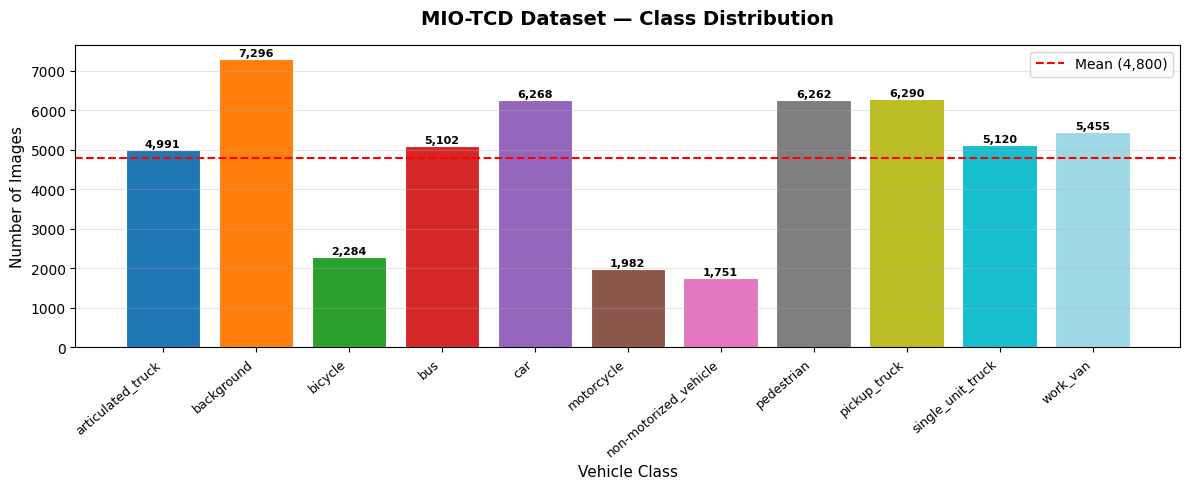

Figure saved to saved_models/class_distribution.png


In [ ]:
# CLASS DISTRIBUTION TABLE AND BAR CHART

# Count images per class in the full dataset
class_counts = []
for cls_name in CLASS_NAMES:
    idx   = CLASS_TO_IDX[cls_name]
    count = int(np.sum(all_labels == idx))
    class_counts.append(count)

total_images = sum(class_counts)
max_count    = max(class_counts)
min_count    = min(class_counts)
imbalance_ratio = max_count / min_count

print(f"{'Class':<28} {'Count':>6}  {'% of Total':>10}  {'Imbalance':>10}")
print("-" * 62)
for cls_name, count in zip(CLASS_NAMES, class_counts):
    pct    = count / total_images * 100
    ratio  = count / min_count
    bar    = "█" * int(ratio * 3)
    print(f"{cls_name:<28} {count:>6,}  {pct:>9.1f}%  {ratio:>8.2f}×  {bar}")

print("-" * 62)
print(f"{'TOTAL':<28} {total_images:>6,}  {'100.0%':>10}")
print(f"\nMax / Min ratio: {imbalance_ratio:.1f}×  "
      f"({'Moderate imbalance — class weights recommended' if imbalance_ratio > 2 else 'Mild imbalance'})")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
bars   = ax.bar(CLASS_NAMES, class_counts, color=colors, edgecolor='white', linewidth=0.8)

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{count:,}", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title("MIO-TCD Dataset — Class Distribution", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Vehicle Class", fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=9)
ax.axhline(y=total_images / NUM_CLASSES, color='red', linestyle='--', linewidth=1.5,
           label=f"Mean ({total_images//NUM_CLASSES:,})")
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / "class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to saved_models/class_distribution.png")

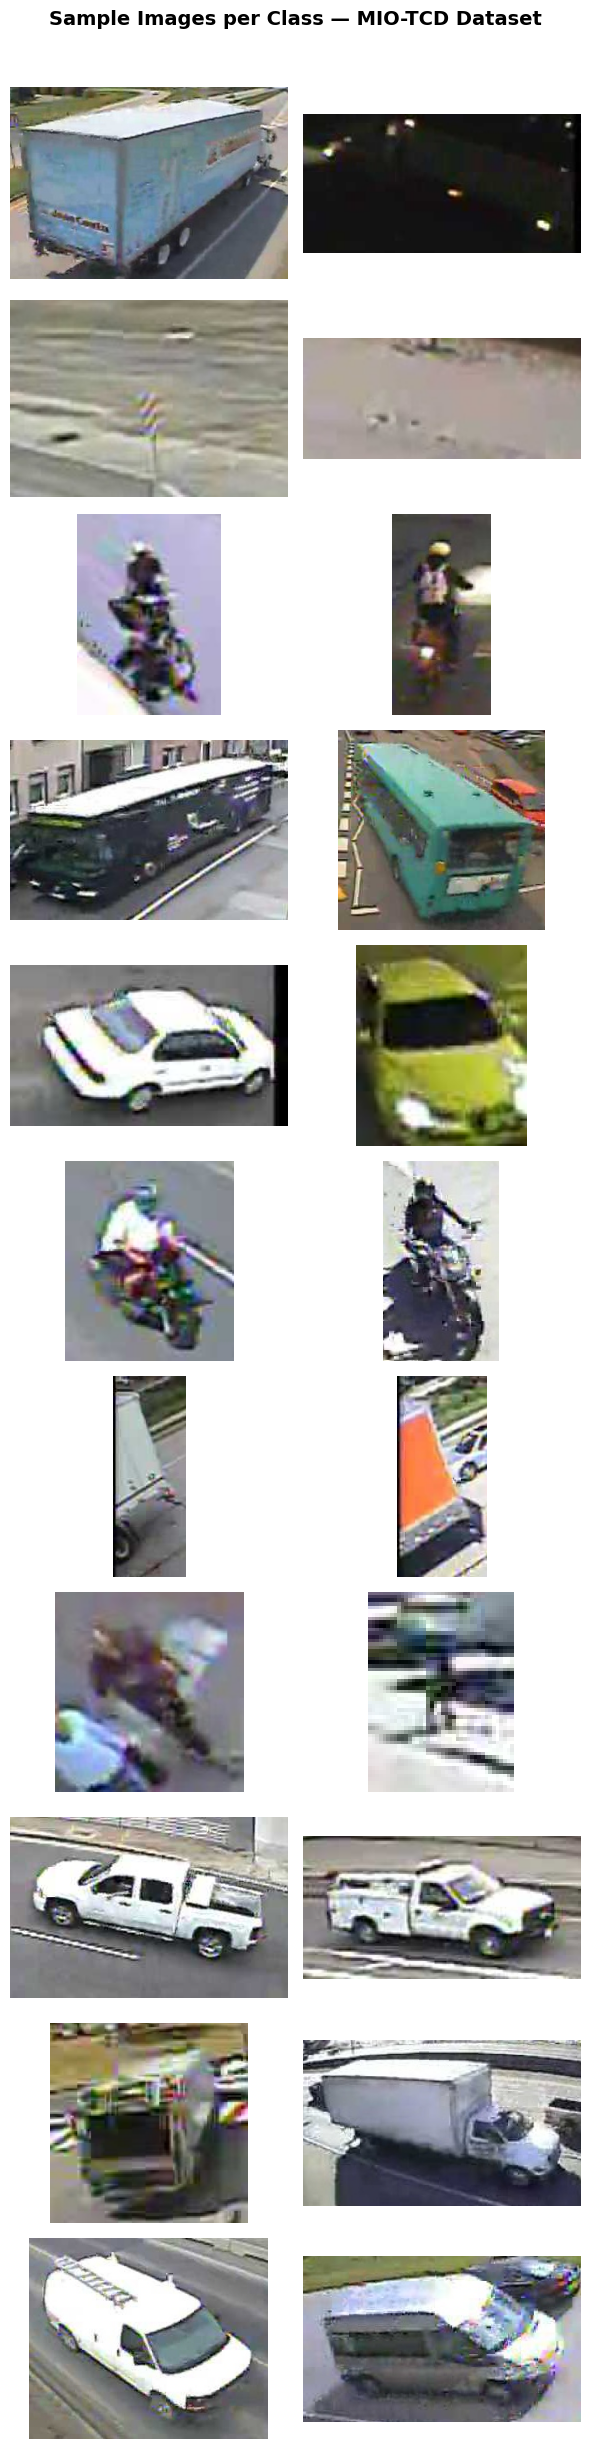

Sample grid saved.

Observations:
  • Images are low-resolution CCTV crops — limited fine detail.
  • 'pickup_truck', 'work_van', and 'single_unit_truck' share similar boxy silhouettes.
  • 'pedestrian' and 'non-motorized_vehicle' may appear visually similar at low resolution.
  • 'background' images show road/sky without any vehicle — a useful negative class.


In [ ]:
# SAMPLE IMAGES GRID (2 images per class)


SAMPLES_PER_CLASS = 2
fig, axes = plt.subplots(NUM_CLASSES, SAMPLES_PER_CLASS,
                         figsize=(SAMPLES_PER_CLASS * 3, NUM_CLASSES * 2.2))
fig.suptitle("Sample Images per Class — MIO-TCD Dataset",
             fontsize=14, fontweight='bold', y=1.01)

for row, cls_name in enumerate(CLASS_NAMES):
    cls_idx    = CLASS_TO_IDX[cls_name]
    cls_paths  = all_paths[all_labels == cls_idx]
    rng        = np.random.default_rng(SEED + row)
    chosen     = rng.choice(cls_paths, size=min(SAMPLES_PER_CLASS, len(cls_paths)),
                            replace=False)
    for col, img_path in enumerate(chosen):
        try:
            img = plt.imread(img_path)
        except Exception:
            img = np.zeros((32, 32, 3), dtype=np.uint8)

        ax = axes[row, col]
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls_name.replace('_', '\n'), fontsize=8,
                          rotation=0, labelpad=60, va='center', ha='right')

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / "sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("Sample grid saved.")
print("\nObservations:")
print("  • Images are low-resolution CCTV crops — limited fine detail.")
print("  • 'pickup_truck', 'work_van', and 'single_unit_truck' share similar boxy silhouettes.")
print("  • 'pedestrian' and 'non-motorized_vehicle' may appear visually similar at low resolution.")
print("  • 'background' images show road/sky without any vehicle — a useful negative class.")

In [ ]:
# IMAGE LOADING AND PREPROCESSING FUNCTION

AUTOTUNE = tf.data.AUTOTUNE

def load_image(path: tf.Tensor, label: tf.Tensor):
    """
    Reads one image from disk, decodes it, resizes it,
    and scales pixel values to [0, 1].
    Works with JPEG, PNG, BMP, and TIFF formats.
    """
    raw   = tf.io.read_file(path)
    img   = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img   = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img   = tf.cast(img, tf.float32) / 255.0
    return img, label


def make_dataset(paths, labels, shuffle=False, augment_in_pipeline=False):
    """
    Builds a tf.data.Dataset from arrays of file paths and integer labels.

    Args:
        paths   : numpy array of string image paths
        labels  : numpy array of integer class indices
        shuffle : whether to shuffle (True for training set only)
    Returns:
        A batched, prefetched tf.data.Dataset
    """
    ds = tf.data.Dataset.from_tensor_slices(
        (paths.astype(str), labels.astype(np.int32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


# Build datasets
train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  shuffle=False)

# Calculate steps per epoch
STEPS_PER_EPOCH     = len(X_train) // BATCH_SIZE
VALIDATION_STEPS    = len(X_val)   // BATCH_SIZE
TEST_STEPS          = len(X_test)  // BATCH_SIZE

print("tf.data pipelines created successfully.")
print(f"  Training steps / epoch : {STEPS_PER_EPOCH:,}")
print(f"  Validation steps       : {VALIDATION_STEPS:,}")
print(f"  Test steps             : {TEST_STEPS:,}")

tf.data pipelines created successfully.
  Training steps / epoch : 1,154
  Validation steps       : 247
  Test steps             : 247


Image batch shape : (32, 128, 128, 3)
Label batch shape : (32,)
Pixel value range : [0.000, 1.000]


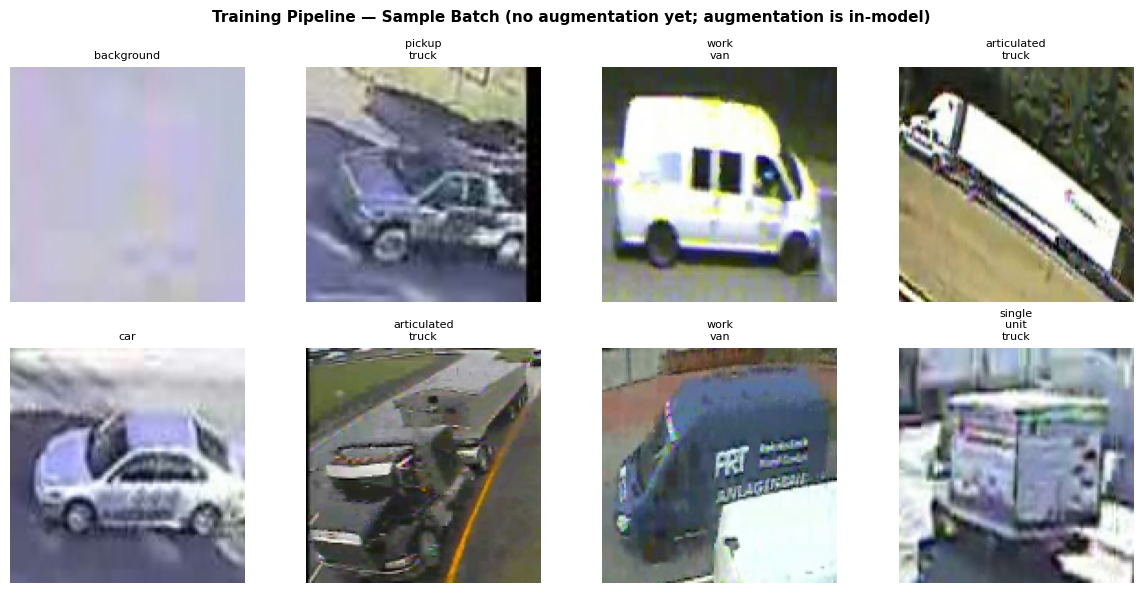

Pipeline verified. Images look correct.


In [ ]:
# VERIFY PIPELINE (sanity check before training)

# Take one batch and check shapes
for img_batch, lbl_batch in train_ds.take(1):
    print(f"Image batch shape : {img_batch.shape}")
    print(f"Label batch shape : {lbl_batch.shape}")
    print(f"Pixel value range : [{img_batch.numpy().min():.3f}, "
          f"{img_batch.numpy().max():.3f}]")

# Visualize a small sample from the training batch
sample_imgs  = img_batch[:8].numpy()
sample_lbls  = lbl_batch[:8].numpy()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Training Pipeline — Sample Batch (no augmentation yet; augmentation is in-model)",
             fontsize=11, fontweight='bold')

for ax, img, lbl in zip(axes.flatten(), sample_imgs, sample_lbls):
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[lbl].replace('_', '\n'), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Pipeline verified. Images look correct.")

In [ ]:
# CUSTOM CNN DEFINITION (Educational Comparison)

def build_custom_cnn(num_classes: int, img_size: int) -> keras.Model:
    """
    A simple 3-block CNN trained from scratch.
    This is intentionally small and is used only for comparison purposes.
    """
    inp = keras.Input(shape=(img_size, img_size, 3), name="input")

    # Mild augmentation (same strategy as MobileNetV2 model) ---
    x = layers.RandomFlip("horizontal")(inp)
    x = layers.RandomRotation(0.08)(x)
    x = layers.RandomZoom(0.10)(x)

    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=regularizers.l2(1e-4),
                       name="output")(x)

    model = keras.Model(inp, out, name="CustomCNN")
    return model


custom_cnn = build_custom_cnn(NUM_CLASSES, IMG_SIZE)
custom_cnn.summary()
print(f"\nTotal trainable parameters: "
      f"{sum(v.numpy().size for v in custom_cnn.trainable_variables):,}")

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,339 (372.42 KB)

 Trainable params: 94,891 (370.67 KB)

 Non-trainable params: 448 (1.75 KB)


Total trainable parameters: 94,891


In [ ]:
# CUSTOM CNN TRAINING

CUSTOM_STEPS = 200
CUSTOM_VAL_STEPS = 75

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Custom CNN for 3 epochs (limited steps — educational only)...")
history_custom = custom_cnn.fit(
    train_ds.repeat(),
    steps_per_epoch=CUSTOM_STEPS,
    epochs=3,
    validation_data=val_ds,
    validation_steps=CUSTOM_VAL_STEPS,
    verbose=1
)

Training Custom CNN for 3 epochs (limited steps — educational only)...
Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.2812 - loss: 2.0792 - val_accuracy: 0.1346 - val_loss: 3.8480
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.3413 - loss: 1.9045 - val_accuracy: 0.1513 - val_loss: 2.9405
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.3852 - loss: 1.7957 - val_accuracy: 0.2654 - val_loss: 2.2267


In [ ]:
# CUSTOM CNN EVALUATION (Educational Comparison)

custom_loss, custom_acc = custom_cnn.evaluate(
    val_ds, steps=CUSTOM_VAL_STEPS, verbose=0
)
print(f"Custom CNN — Validation Accuracy: {custom_acc*100:.2f}%")
print(f"Custom CNN — Validation Loss    : {custom_loss:.4f}")
print()
print("Key takeaway:")
print("  • Custom CNN trains only on MIO-TCD data from scratch.")
print("  • Without pretrained features, it struggles with low-res CCTV images.")
print("  • MobileNetV2 (Section E.2) will significantly outperform this baseline.")

Custom CNN — Validation Accuracy: 26.54%
Custom CNN — Validation Loss    : 2.2267

Key takeaway:
  • Custom CNN trains only on MIO-TCD data from scratch.
  • Without pretrained features, it struggles with low-res CCTV images.
  • MobileNetV2 (Section E.2) will significantly outperform this baseline.


In [ ]:
# BUILD MOBILENETV2 MODEL (Main Model)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.15),
], name="data_augmentation")

# Pretrained backbone
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

print(f"MobileNetV2 backbone loaded.")
print(f"  Total layers in backbone  : {len(base_model.layers)}")
print(f"  Trainable at Stage 1      : {sum(1 for l in base_model.layers if l.trainable)}")

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_images")

# Step 1: Augment (only active during model.fit)
x = data_augmentation(inputs)

# Step 2: Rescale [0,1] → [-1,1]
x = layers.Rescaling(scale=2.0, offset=-1.0, name="mobilenet_preprocess")(x)

# Step 3: MobileNetV2 feature extraction
x = base_model(x, training=False)

# Step 4: Classification head
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.35, name="dropout")(x)
outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    kernel_regularizer=regularizers.l2(1e-4),
    name="predictions"
)(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2_VehicleClassifier")

print(f"\nFull model built successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 backbone loaded.
  Total layers in backbone  : 154
  Trainable at Stage 1      : 0

Full model built successfully.


In [ ]:
# MODEL SUMMARY

# Show parameter counts
total_params     = model.count_params()
trainable_params = sum(v.numpy().size for v in model.trainable_variables)
frozen_params    = total_params - trainable_params

print("=" * 55)
print("       MOBILENETV2 MODEL PARAMETER SUMMARY")
print("=" * 55)
print(f"  Total parameters      : {total_params:>10,}")
print(f"  Trainable (Stage 1)   : {trainable_params:>10,}  ← Head only")
print(f"  Frozen (Stage 1)      : {frozen_params:>10,}  ← Full backbone")
print("=" * 55)
print()
print("Architecture: Input → Augmentation → Rescaling")
print("           → MobileNetV2 backbone (frozen)")
print("           → GlobalAveragePooling2D")
print("           → Dropout(0.35)")
print("           → Dense(11, softmax) + L2")
print()
# Detailed summary
model.summary(line_length=80, expand_nested=False)

       MOBILENETV2 MODEL PARAMETER SUMMARY
  Total parameters      :  2,272,075
  Trainable (Stage 1)   :     14,091  ← Head only
  Frozen (Stage 1)      :  2,257,984  ← Full backbone

Architecture: Input → Augmentation → Rescaling
           → MobileNetV2 backbone (frozen)
           → GlobalAveragePooling2D
           → Dropout(0.35)
           → Dense(11, softmax) + L2



Model: "MobileNetV2_VehicleClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_images (InputLayer)         │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ data_augmentation (Sequential)    │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenet_preprocess (Rescaling)  │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128 (Functional) │ (None, 4, 4, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 11)               │        14,091 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,272,075 (8.67 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# COMPUTE CLASS WEIGHTS

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_array)}

print("Class weights (higher = rarer class, gets higher loss penalty):")
print()
print(f"{'Class':<28} {'Weight':>8}")
print("-" * 40)
for idx, cls_name in enumerate(CLASS_NAMES):
    marker = "  ← rare (boosted)" if class_weight_dict[idx] > 1.5 else ""
    print(f"  {cls_name:<26} {class_weight_dict[idx]:>8.4f}{marker}")

Class weights (higher = rarer class, gets higher loss penalty):

Class                          Weight
----------------------------------------
  articulated_truck            0.9619
  background                   0.6579
  bicycle                      2.1026  ← rare (boosted)
  bus                          0.9406
  car                          0.7657
  motorcycle                   2.4207  ← rare (boosted)
  non-motorized_vehicle        2.7428  ← rare (boosted)
  pedestrian                   0.7666
  pickup_truck                 0.7633
  single_unit_truck            0.9375
  work_van                     0.8798


In [ ]:
# PLOT TRAINING HISTORY

def plot_history(history_obj, stage_label="", epoch_offset=0, save_path=None):
    """
    Plots accuracy and loss curves for a training history object.

    Args:
        history_obj   : keras History object (or dict with same keys)
        stage_label   : label for the title (e.g., 'Stage 1 — Frozen Backbone')
        epoch_offset  : used when plotting Stage 2 to continue x-axis from Stage 1
        save_path     : optional Path to save the figure as PNG
    """
    if isinstance(history_obj, dict):
        h = history_obj
    else:
        h = history_obj.history

    n_epochs     = len(h['accuracy'])
    epoch_range  = range(epoch_offset + 1, epoch_offset + n_epochs + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Training History — {stage_label}", fontsize=13, fontweight='bold')

    # Accuracy
    ax1.plot(epoch_range, h['accuracy'],     'b-o', label='Train Acc',  linewidth=2, markersize=4)
    ax1.plot(epoch_range, h['val_accuracy'], 'r-o', label='Val Acc',    linewidth=2, markersize=4)
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])

    # Annotate final values
    ax1.annotate(f"{h['accuracy'][-1]:.3f}",
                 xy=(epoch_range[-1], h['accuracy'][-1]), fontsize=9, color='blue')
    ax1.annotate(f"{h['val_accuracy'][-1]:.3f}",
                 xy=(epoch_range[-1], h['val_accuracy'][-1]), fontsize=9, color='red')

    # Loss
    ax2.plot(epoch_range, h['loss'],     'b-o', label='Train Loss', linewidth=2, markersize=4)
    ax2.plot(epoch_range, h['val_loss'], 'r-o', label='Val Loss',   linewidth=2, markersize=4)
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved: {save_path}")
    plt.show()


print("plot_history() helper defined.")

plot_history() helper defined.


In [ ]:
# CALLBACKS

def get_callbacks(checkpoint_path, stage_label=""):
    """Returns the standard set of training callbacks."""
    cb_early = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
    cb_ckpt = keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,          # Only save if val_loss improved
        verbose=1
    )
    cb_reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
    return [cb_early, cb_ckpt, cb_reduce_lr]


print("Callbacks defined:")
print("  ✓ EarlyStopping       (patience=6, restore_best_weights=True)")
print("  ✓ ModelCheckpoint     (save_best_only=True, monitors val_loss)")
print("  ✓ ReduceLROnPlateau   (factor=0.5, patience=3, min_lr=1e-7)")

Callbacks defined:
  ✓ EarlyStopping       (patience=6, restore_best_weights=True)
  ✓ ModelCheckpoint     (save_best_only=True, monitors val_loss)
  ✓ ReduceLROnPlateau   (factor=0.5, patience=3, min_lr=1e-7)


In [ ]:
# STAGE 1: TRAIN FROZEN BACKBONE

assert not base_model.trainable, "Backbone should be frozen for Stage 1."
print(f"Trainable parameters (Stage 1): "
      f"{sum(v.numpy().size for v in model.trainable_variables):,}  (head only)")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = get_callbacks(STAGE1_CKPT, stage_label="Stage 1")

print(f"\n{'='*55}")
print("  STAGE 1 TRAINING — FROZEN BACKBONE")
print(f"{'='*55}")
print(f"  Max epochs    : {STAGE1_EPOCHS}")
print(f"  Learning rate : {STAGE1_LR}")
print(f"  Checkpoint    : {STAGE1_CKPT}")
print(f"{'='*55}\n")

history_stage1 = model.fit(
    train_ds,
    epochs=STAGE1_EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1,
    verbose=1
)

stage1_epochs_run = len(history_stage1.history['accuracy'])
print(f"\nStage 1 complete. Ran {stage1_epochs_run} epochs.")
print(f"Best val accuracy : "
      f"{max(history_stage1.history['val_accuracy'])*100:.2f}%")
print(f"Best val loss     : "
      f"{min(history_stage1.history['val_loss']):.4f}")

Trainable parameters (Stage 1): 14,091  (head only)

  STAGE 1 TRAINING — FROZEN BACKBONE
  Max epochs    : 20
  Learning rate : 0.001
  Checkpoint    : C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\best_stage1.keras

Epoch 1/20
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.5026 - loss: 1.5896
Epoch 1: val_loss improved from None to 0.90212, saving model to C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\best_stage1.keras

Epoch 1: finished saving model to C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\best_stage1.keras
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 718s 616ms/step - accuracy: 0.5804 - loss: 1.3085 - val_accuracy: 0.6880 - val_loss: 0.9021 - learning_rate: 0.0010
Epoch 2/20
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.6522 - loss: 1.0689
Epoch 2: val_loss improved from 0.90212 to 0.86241, saving model to C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\best_stage1.keras

Epoch 2: finished saving model to C:\Users\asus\OneDrive\Documents

Figure saved: C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\history_stage1.png


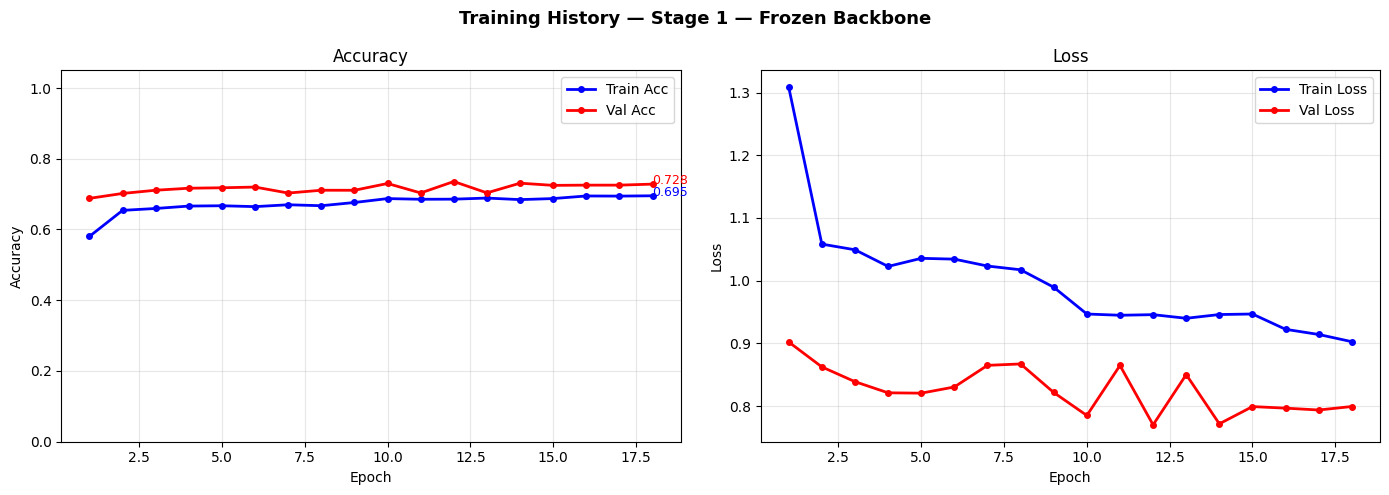

In [ ]:
# STAGE 1 TRAINING CURVES

plot_history(
    history_stage1,
    stage_label="Stage 1 — Frozen Backbone",
    epoch_offset=0,
    save_path=MODEL_SAVE_DIR / "history_stage1.png"
)

In [ ]:
# STAGE 2: PARTIAL FINE-TUNING

# Step 1: Unfreeze the backbone
base_model.trainable = True

# Step 2: Re-freeze all layers EXCEPT the last FINE_TUNE_LAYERS layers
fine_tune_from = len(base_model.layers) - FINE_TUNE_LAYERS
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= fine_tune_from)

# Step 3: Report what's now trainable
total_trainable_now = sum(v.numpy().size for v in model.trainable_variables)
unfrozen_layer_names = [l.name for l in base_model.layers if l.trainable]

print(f"Backbone total layers         : {len(base_model.layers)}")
print(f"Unfrozen from layer index     : {fine_tune_from} (last {FINE_TUNE_LAYERS} layers)")
print(f"Number of unfrozen backbone layers: {len(unfrozen_layer_names)}")
print(f"Total trainable parameters now : {total_trainable_now:,}")

# Step 4: Recompile with much smaller learning rate — MANDATORY after changing trainability
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = get_callbacks(STAGE2_CKPT, stage_label="Stage 2")

print(f"\n{'='*55}")
print("  STAGE 2 TRAINING — PARTIAL FINE-TUNING")
print(f"{'='*55}")
print(f"  Max epochs    : {STAGE2_EPOCHS}")
print(f"  Learning rate : {STAGE2_LR}  (10× smaller than Stage 1 minimum)")
print(f"  Checkpoint    : {STAGE2_CKPT}")
print(f"{'='*55}\n")

history_stage2 = model.fit(
    train_ds,
    epochs=STAGE2_EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2,
    verbose=1
)

stage2_epochs_run = len(history_stage2.history['accuracy'])
print(f"\nStage 2 complete. Ran {stage2_epochs_run} epochs.")
print(f"Best val accuracy : "
      f"{max(history_stage2.history['val_accuracy'])*100:.2f}%")
print(f"Best val loss     : "
      f"{min(history_stage2.history['val_loss']):.4f}")

Backbone total layers         : 154
Unfrozen from layer index     : 124 (last 30 layers)
Number of unfrozen backbone layers: 30
Total trainable parameters now : 1,540,491

  STAGE 2 TRAINING — PARTIAL FINE-TUNING
  Max epochs    : 20
  Learning rate : 1e-05  (10× smaller than Stage 1 minimum)
  Checkpoint    : C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\best_stage2.keras

Epoch 1/20
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.5552 - loss: 1.5739
Epoch 1: val_loss improved from None to 0.83470, saving model to C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\best_stage2.keras

Epoch 1: finished saving model to C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\best_stage2.keras
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 1084s 927ms/step - accuracy: 0.6075 - loss: 1.3047 - val_accuracy: 0.7259 - val_loss: 0.8347 - learning_rate: 1.0000e-05
Epoch 2/20
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.6623 - loss: 1.0455
Epoch 2: val_loss improved from 0.83470 to

Figure saved: C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\history_stage2.png


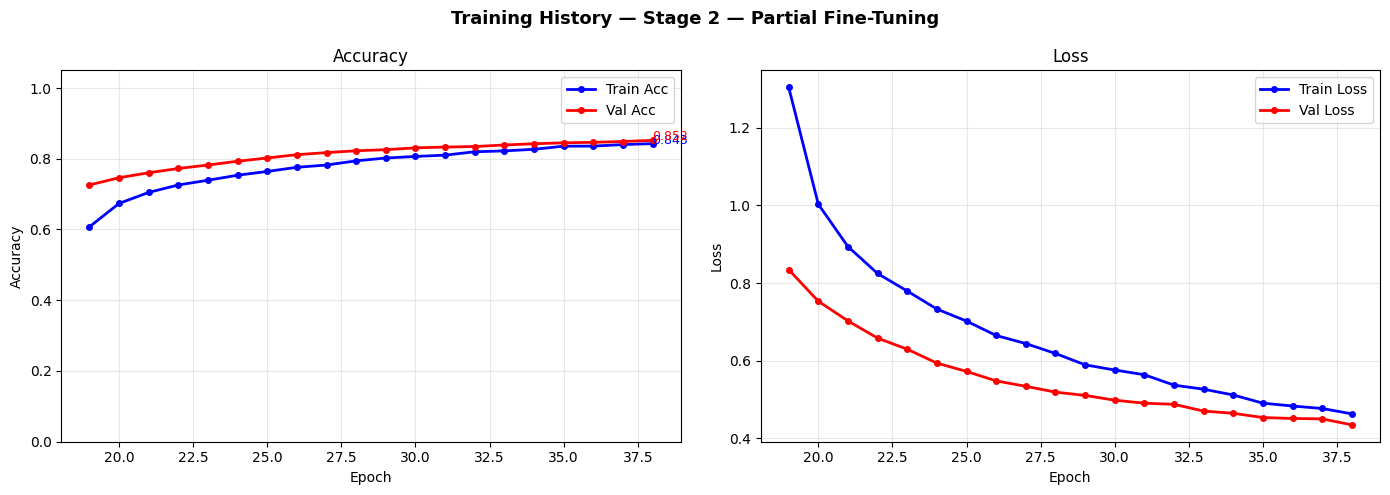

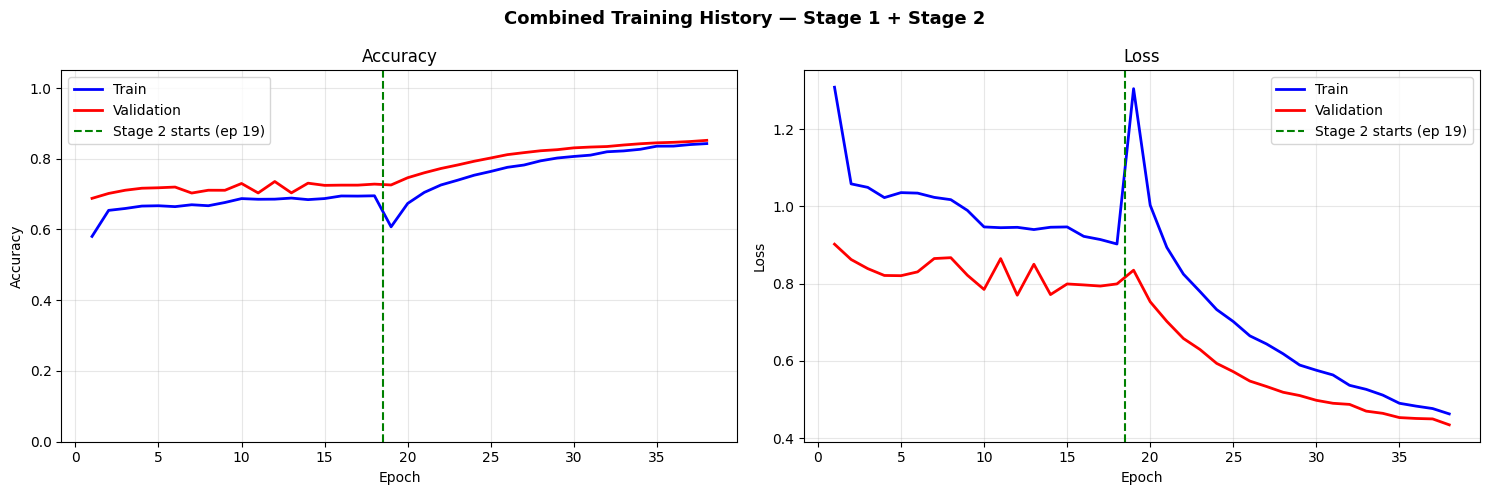

Combined history saved.


In [ ]:
# F.5 — COMBINED TRAINING HISTORY (Stage 1 + Stage 2)

def combine_histories(h1, h2):
    """Merges two Keras History objects into a single dictionary."""
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined


combined_h = combine_histories(history_stage1, history_stage2)
n1 = stage1_epochs_run

# Plot individually first
plot_history(history_stage2,
             stage_label="Stage 2 — Partial Fine-Tuning",
             epoch_offset=n1,
             save_path=MODEL_SAVE_DIR / "history_stage2.png")

# Combined plot
total_epochs   = len(combined_h['accuracy'])
epoch_range    = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Combined Training History — Stage 1 + Stage 2", fontsize=13, fontweight='bold')

for ax, metric, ylabel in [
    (ax1, ('accuracy', 'val_accuracy'), 'Accuracy'),
    (ax2, ('loss',     'val_loss'),     'Loss')
]:
    train_key, val_key = metric
    ax.plot(epoch_range, combined_h[train_key], 'b-',   label='Train',      linewidth=2)
    ax.plot(epoch_range, combined_h[val_key],   'r-',   label='Validation', linewidth=2)
    ax.axvline(x=n1 + 0.5, color='green', linestyle='--', linewidth=1.5,
               label=f'Stage 2 starts (ep {n1+1})')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if ylabel == 'Accuracy':
        ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / "history_combined.png", dpi=150, bbox_inches='tight')
plt.show()
print("Combined history saved.")

In [ ]:
# LOAD BEST MODEL AND EVALUATE ON TEST SET

import os

# Prefer Stage 2 checkpoint; fall back to Stage 1 if Stage 2 was not saved
if os.path.exists(STAGE2_CKPT):
    best_model_path = STAGE2_CKPT
    print(f"Loading best Stage 2 model: {STAGE2_CKPT}")
elif os.path.exists(STAGE1_CKPT):
    best_model_path = STAGE1_CKPT
    print(f"Stage 2 checkpoint not found. Loading Stage 1: {STAGE1_CKPT}")
else:
    # Fall back to in-memory model
    print("No checkpoint found on disk. Using in-memory model weights.")
    best_model_path = None

if best_model_path:
    best_model = keras.models.load_model(best_model_path)
else:
    best_model = model

# Evaluate on test set
print("\nEvaluating on held-out test set...")
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)

print()
print("=" * 50)
print("        FINAL TEST SET RESULTS")
print("=" * 50)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print("=" * 50)
print()
print("  Note: These metrics are computed on data the model")
print("  has NEVER seen during training or validation.")

Loading best Stage 2 model: C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\best_stage2.keras

Evaluating on held-out test set...
248/248 ━━━━━━━━━━━━━━━━━━━━ 144s 565ms/step - accuracy: 0.8546 - loss: 0.4336

        FINAL TEST SET RESULTS
  Test Accuracy : 85.46%
  Test Loss     : 0.4336

  Note: These metrics are computed on data the model
  has NEVER seen during training or validation.


In [ ]:
# GENERATE PREDICTIONS AND CLASSIFICATION REPORT

print("Generating predictions on test set (this may take a minute)...")

# Collect all true labels and predicted labels
y_true_all = []
y_pred_all = []

for img_batch, lbl_batch in test_ds:
    preds = best_model.predict(img_batch, verbose=0)
    y_pred_batch = np.argmax(preds, axis=1)
    y_true_all.extend(lbl_batch.numpy().tolist())
    y_pred_all.extend(y_pred_batch.tolist())

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

overall_acc = np.mean(y_true_all == y_pred_all)
print(f"\nVerified test accuracy from predictions: {overall_acc*100:.2f}%")

# Full classification report
print("\n" + "=" * 65)
print("        PER-CLASS CLASSIFICATION REPORT")
print("=" * 65)
report = classification_report(
    y_true_all,
    y_pred_all,
    target_names=CLASS_NAMES,
    digits=4
)
print(report)

# Save report to file
report_path = MODEL_SAVE_DIR / "classification_report.txt"
with open(report_path, 'w') as f:
    f.write(f"Test Accuracy: {overall_acc*100:.2f}%\n\n")
    f.write(report)
print(f"Classification report saved: {report_path}")

Generating predictions on test set (this may take a minute)...

Verified test accuracy from predictions: 85.46%

        PER-CLASS CLASSIFICATION REPORT
                       precision    recall  f1-score   support

    articulated_truck     0.7337    0.8278    0.7779       749
           background     0.9780    0.9352    0.9561      1095
              bicycle     0.8280    0.8280    0.8280       343
                  bus     0.9229    0.9229    0.9229       765
                  car     0.9168    0.8787    0.8973       940
           motorcycle     0.8972    0.8519    0.8739       297
non-motorized_vehicle     0.5376    0.7605    0.6299       263
           pedestrian     0.9186    0.9010    0.9097       939
         pickup_truck     0.8445    0.8919    0.8676       944
    single_unit_truck     0.7342    0.6940    0.7135       768
             work_van     0.8795    0.7763    0.8247       818

             accuracy                         0.8546      7921
            macro avg     

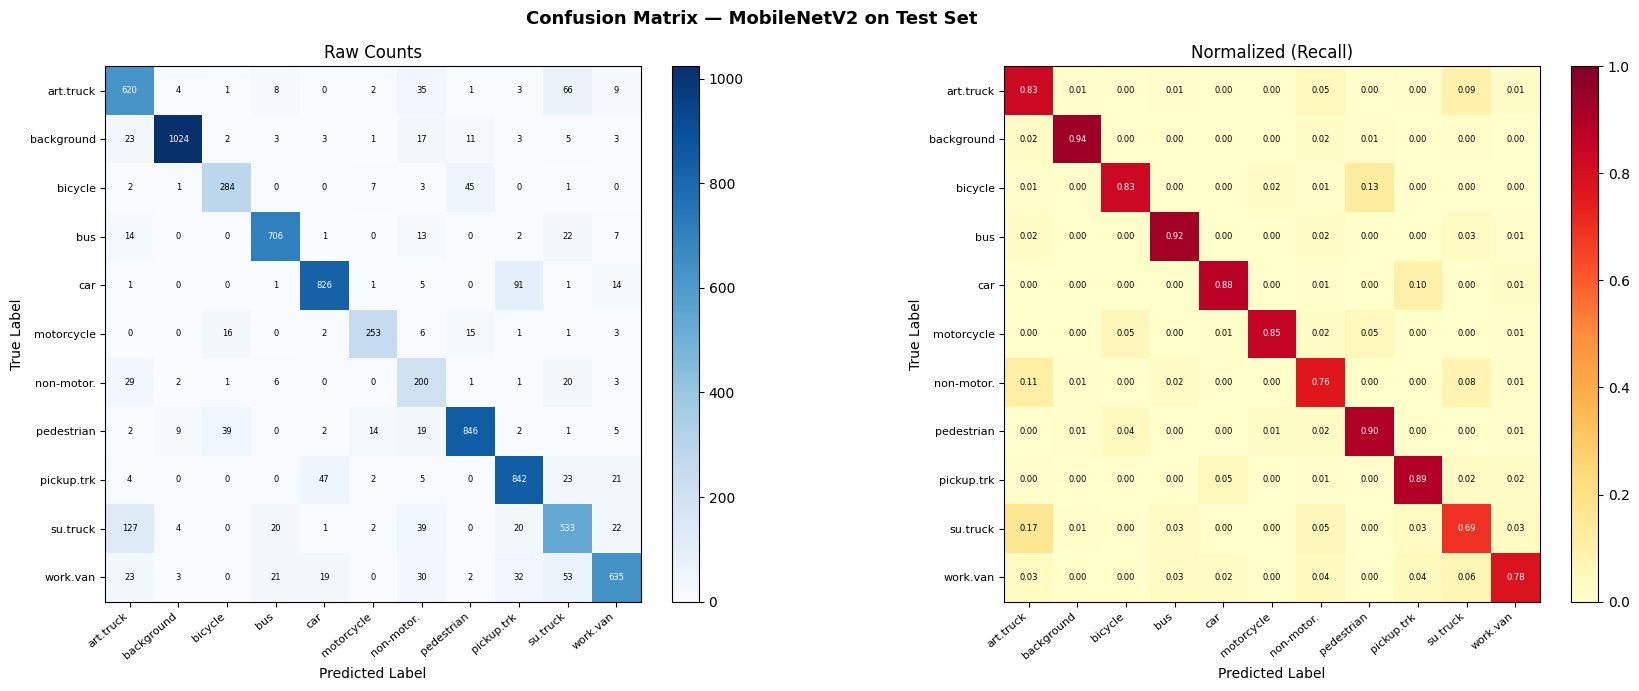

Confusion matrix saved.


In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_true_all, y_pred_all)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Use short class labels for readability in the plot
short_names = [
    "art.truck", "background", "bicycle", "bus", "car",
    "motorcycle", "non-motor.", "pedestrian", "pickup.trk",
    "su.truck",  "work.van"
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix — MobileNetV2 on Test Set", fontsize=13, fontweight='bold')

for ax, data, fmt, title, cmap in [
    (axes[0], cm,            'd',    "Raw Counts",        'Blues'),
    (axes[1], cm_normalized, '.2f',  "Normalized (Recall)", 'YlOrRd'),
]:
    im = ax.imshow(data, interpolation='nearest', cmap=cmap, vmin=0,
                   vmax=(1 if fmt == '.2f' else cm.max()))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ticks = np.arange(NUM_CLASSES)
    ax.set(xticks=ticks, yticks=ticks,
           xticklabels=short_names, yticklabels=short_names,
           title=title, ylabel="True Label", xlabel="Predicted Label")
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)

    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt),
                    ha='center', va='center', fontsize=6,
                    color='white' if data[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / "confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

         GENERALIZATION ANALYSIS
  Best train accuracy (at best val epoch) : 84.29%
  Best validation accuracy                : 85.20%
  Test accuracy                           : 85.46%
  Train–Val gap                           : -0.92%

--- DIAGNOSIS ---
  ✓ Model appears WELL-GENERALIZED.
    Train–Val gap (-0.9%) is within acceptable range.
    Test accuracy (85.46%) is consistent with validation.
  Suggestions for further improvement:
    → Test on real traffic camera footage to validate real-world performance
    → Consider Test-Time Augmentation (TTA) for marginal gains
    → Ensemble with a second MobileNetV2 trained on a different split


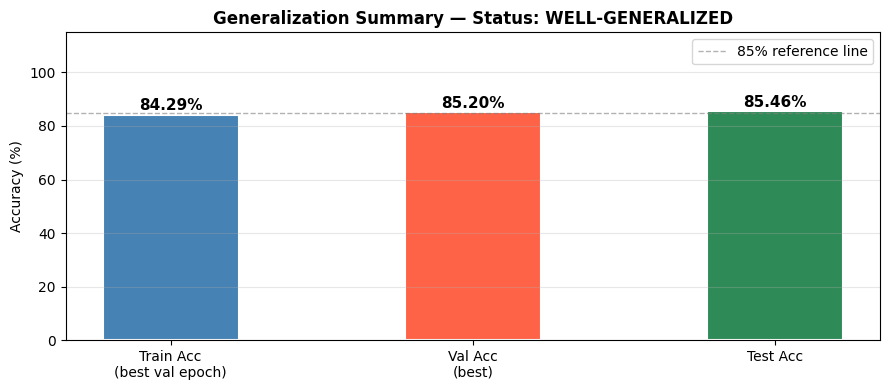

In [ ]:
# OVERFITTING / UNDERFITTING ANALYSIS

final_train_acc = combined_h['accuracy'][-1]
final_val_acc   = combined_h['val_accuracy'][-1]
best_val_acc    = max(combined_h['val_accuracy'])
best_train_acc  = max(combined_h['accuracy'])

# Use the best epochs for a fair comparison
best_val_idx   = np.argmax(combined_h['val_accuracy'])
train_at_best  = combined_h['accuracy'][best_val_idx]
gap            = train_at_best - best_val_acc

print("=" * 60)
print("         GENERALIZATION ANALYSIS")
print("=" * 60)
print(f"  Best train accuracy (at best val epoch) : {train_at_best*100:.2f}%")
print(f"  Best validation accuracy                : {best_val_acc*100:.2f}%")
print(f"  Test accuracy                           : {overall_acc*100:.2f}%")
print(f"  Train–Val gap                           : {gap*100:.2f}%")
print("=" * 60)

# Diagnosis
print("\n--- DIAGNOSIS ---")
if gap > 0.15:
    status = "OVERFITTING"
    print(f"  ⚠ OVERFITTING detected (gap = {gap*100:.1f}%)")
    print("  Recommendations:")
    print("    → Increase Dropout rate (e.g., 0.4–0.5)")
    print("    → Add more aggressive augmentation")
    print("    → Collect more training data or apply MixUp")
    print("    → Increase L2 regularization weight")
elif best_val_acc < 0.72:
    status = "UNDERFITTING"
    print(f"  ⚠ UNDERFITTING detected (val acc = {best_val_acc*100:.1f}%)")
    print("  Recommendations:")
    print("    → Unfreeze more backbone layers (increase FINE_TUNE_LAYERS)")
    print("    → Train for more epochs (increase STAGE2_EPOCHS)")
    print("    → Reduce Dropout slightly (e.g., 0.2)")
    print("    → Try a slightly larger image size (e.g., 160×160)")
else:
    status = "WELL-GENERALIZED"
    print(f"  ✓ Model appears WELL-GENERALIZED.")
    print(f"    Train–Val gap ({gap*100:.1f}%) is within acceptable range.")
    print(f"    Test accuracy ({overall_acc*100:.2f}%) is consistent with validation.")
    print("  Suggestions for further improvement:")
    print("    → Test on real traffic camera footage to validate real-world performance")
    print("    → Consider Test-Time Augmentation (TTA) for marginal gains")
    print("    → Ensemble with a second MobileNetV2 trained on a different split")

# Visualize the gap
fig, ax = plt.subplots(figsize=(9, 4))
x_pos   = ['Train Acc\n(best val epoch)', 'Val Acc\n(best)', 'Test Acc']
y_vals  = [train_at_best, best_val_acc, overall_acc]
colors_diag = ['steelblue', 'tomato', 'seagreen']
bars = ax.bar(x_pos, [v * 100 for v in y_vals], color=colors_diag, width=0.45,
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, y_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val*100:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim([0, 115])
ax.set_title(f"Generalization Summary — Status: {status}", fontsize=12, fontweight='bold')
ax.set_ylabel("Accuracy (%)")
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=85, color='gray', linestyle='--', linewidth=1, alpha=0.6,
           label='85% reference line')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / "generalization_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SAVE FINAL MODEL AND CLASS INDEX MAPPING

final_model_path = MODEL_SAVE_DIR / "vehicle_classifier_final.keras"
best_model.save(final_model_path)
print(f"✓ Final model saved: {final_model_path}")

# Save class name → index and index → class name mappings
class_map = {
    "class_names"  : CLASS_NAMES,              # List: index → name
    "class_to_idx" : CLASS_TO_IDX,             # Dict: name → index
    "idx_to_class" : {str(k): v for k, v in IDX_TO_CLASS.items()},  # JSON keys must be str
    "num_classes"  : NUM_CLASSES,
    "img_size"     : IMG_SIZE
}

with open(CLASS_JSON, 'w') as f:
    json.dump(class_map, f, indent=2)
print(f"✓ Class mapping saved: {CLASS_JSON}")

print()
print("Saved files:")
for p in sorted(MODEL_SAVE_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<45} ({size_kb:>8.1f} KB)")

✓ Final model saved: C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\vehicle_classifier_final.keras
✓ Class mapping saved: C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\class_names.json

Saved files:
  best_stage1.keras                             (  9577.1 KB)
  best_stage2.keras                             ( 21524.5 KB)
  class_distribution.png                        (    85.6 KB)
  class_names.json                              (     0.8 KB)
  classification_report.txt                     (     1.0 KB)
  confusion_matrix.png                          (   139.9 KB)
  generalization_summary.png                    (    39.3 KB)
  history_combined.png                          (    93.9 KB)
  history_stage1.png                            (    78.4 KB)
  history_stage2.png                            (    77.1 KB)
  sample_images.png                             (  1953.8 KB)
  vehicle_classifier_final.keras                ( 21518.9 KB)


In [ ]:
# DEMONSTRATE MODEL RELOAD FOR FUTURE INFERENCE

print("--- Demonstrating model reload ---\n")

# Load class mapping
with open(CLASS_JSON, 'r') as f:
    loaded_class_map = json.load(f)

loaded_class_names = loaded_class_map['class_names']
loaded_img_size    = loaded_class_map['img_size']

print(f"Loaded class names  : {loaded_class_names}")
print(f"Loaded image size   : {loaded_img_size}")

# Load model
loaded_model = keras.models.load_model(final_model_path)
print(f"\nLoaded model input shape : {loaded_model.input_shape}")
print(f"Loaded model output shape: {loaded_model.output_shape}")

# Quick sanity check — one batch from the test set
for img_batch, lbl_batch in test_ds.take(1):
    preds    = loaded_model.predict(img_batch, verbose=0)
    top_pred = np.argmax(preds, axis=1)
    match    = np.mean(top_pred == lbl_batch.numpy())
    print(f"\nSanity check batch accuracy: {match*100:.1f}%")
    print("Model reloaded and working correctly. ✓")
    break

In [ ]:
# INFERENCE ON CUSTOM TEST FOLDER

# Check inference folder
if not INFERENCE_DIR.exists():
    raise FileNotFoundError(
        f"\n[ERROR] Inference folder not found: {INFERENCE_DIR}\n"
        "Create the folder and add some CCTV vehicle images before running this cell."
    )

# Collect valid image paths
inference_image_paths = [
    p for p in INFERENCE_DIR.iterdir()
    if p.suffix.lower() in VALID_EXTENSIONS
]

if len(inference_image_paths) == 0:
    raise ValueError(f"No images found in {INFERENCE_DIR}. "
                     "Add .jpg or .png images and rerun.")

print(f"Found {len(inference_image_paths)} image(s) in inference folder.")

# Randomly select 5 images
N_INFERENCE = min(5, len(inference_image_paths))
rng_inf     = random.Random(SEED + 999)
selected    = rng_inf.sample(inference_image_paths, k=N_INFERENCE)
print(f"Randomly selected {N_INFERENCE} images for inference:")
for p in selected:
    print(f"  → {p.name}")

In [ ]:
# INFERENCE — PREPROCESS, PREDICT, AND DISPLAY

def preprocess_single_image(img_path: Path, img_size: int) -> np.ndarray:
    """
    Loads and preprocesses a single image for model inference.
    Output: float32 numpy array of shape (1, img_size, img_size, 3) in [0, 1] range.
    The model's internal Rescaling layer handles the [0,1] → [-1,1] conversion.
    """
    img = tf.io.read_file(str(img_path))
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.cast(img, tf.float32) / 255.0   # [0, 1]
    return img.numpy()


def predict_image(model, img_array: np.ndarray, class_names: list, top_k: int = 3):
    """
    Runs inference on a single preprocessed image.

    Returns:
        top_k_indices      : int array of top-k predicted class indices
        top_k_confidences  : float array of corresponding probabilities
    """
    batch        = np.expand_dims(img_array, axis=0)
    probs        = model.predict(batch, verbose=0)[0]
    top_k_idx    = np.argsort(probs)[::-1][:top_k]
    top_k_conf   = probs[top_k_idx]
    return top_k_idx, top_k_conf


# Run inference and display results
fig, axes = plt.subplots(1, N_INFERENCE, figsize=(N_INFERENCE * 4, 5.5))
if N_INFERENCE == 1:
    axes = [axes]

fig.suptitle("Inference Results — MobileNetV2 Vehicle Classifier",
             fontsize=13, fontweight='bold', y=1.02)

for ax, img_path in zip(axes, selected):
    img_array = preprocess_single_image(img_path, IMG_SIZE)

    top_idx, top_conf = predict_image(loaded_model, img_array,
                                      loaded_class_names, top_k=3)

    top1_class = loaded_class_names[top_idx[0]]
    top1_conf  = top_conf[0]

    display_img = plt.imread(str(img_path))
    ax.imshow(display_img)
    ax.axis('off')

    conf_color = 'green' if top1_conf >= 0.70 else ('orange' if top1_conf >= 0.45 else 'red')
    ax.set_title(f"{top1_class.replace('_', ' ')}\n{top1_conf*100:.1f}%",
                 fontsize=10, fontweight='bold', color=conf_color, pad=6)

    top3_text = "\n".join([
        f"#{i+1} {loaded_class_names[idx].replace('_', ' ')}: {conf*100:.1f}%"
        for i, (idx, conf) in enumerate(zip(top_idx, top_conf))
    ])
    ax.annotate(top3_text,
                xy=(0.01, -0.02), xycoords='axes fraction',
                fontsize=7.5, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                          edgecolor='gray', alpha=0.9))

    print(f"\nImage: {img_path.name}")
    print(f"  Top-1: {top1_class:<28} ({top1_conf*100:.2f}%)")
    for rank, (idx, conf) in enumerate(zip(top_idx[1:], top_conf[1:]), start=2):
        print(f"  Top-{rank}: {loaded_class_names[idx]:<28} ({conf*100:.2f}%)")

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / "inference_results.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nInference figure saved: {MODEL_SAVE_DIR / 'inference_results.png'}")
print("\nInference complete. ✓")